# 프로젝트 1 : 순수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

## 프로젝트 목표

Diabetes 데이터를 활용하여 당뇨병 환자의 혈당 수치(target)를 예측하는 선형회귀 모델을 직접 구현한다.

---


In [13]:
##라이브러리 및 데이터 불러오기

from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# 당뇨병 데이터셋 불러오기
data = load_diabetes()

# BMI 변수만 사용
X = data.data[:, 2]

# 정답값
y = data.target

print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (442,)
y shape : (442,)


In [15]:
##데이터 확인

# BMI 데이터 확인용 DataFrame 생성
df = pd.DataFrame({
    "bmi": X,
    "target": y
})

df.head()

,bmi,target
0,0.061696,151.0
1,-0.051474,75.0
2,0.044451,141.0
3,-0.011595,206.0
4,-0.036385,135.0


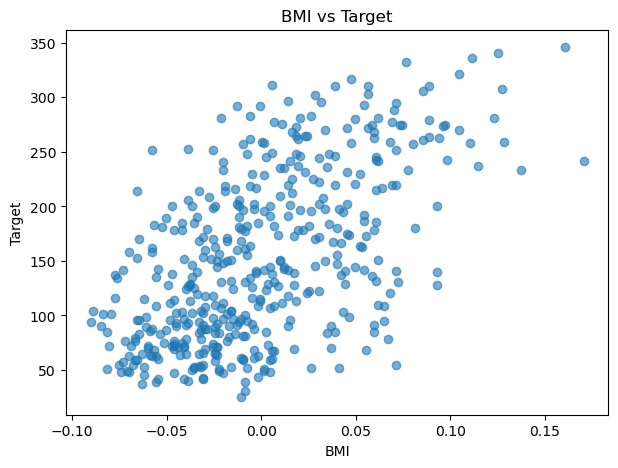

In [16]:
##데이터 시각화

# BMI와 target 관계 확인
plt.figure(figsize=(7,5))

plt.scatter(
    X,
    y,
    alpha=0.6
)

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("BMI vs Target")

plt.show()

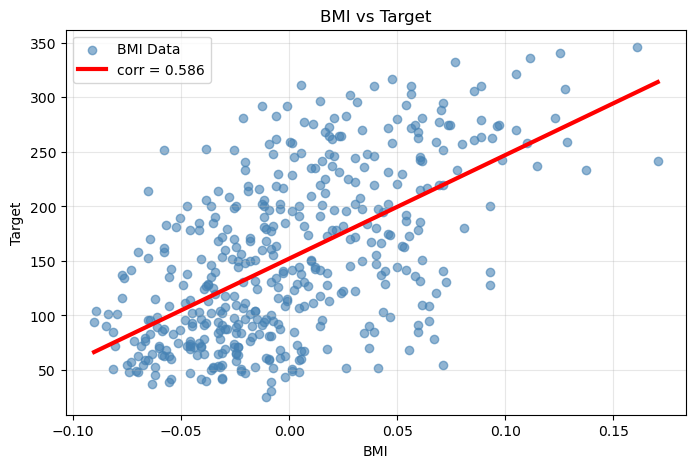

상관계수 : 0.586


In [17]:
# BMI와 target 관계 시각화

import numpy as np
import matplotlib.pyplot as plt

# BMI와 target의 상관계수 계산
corr = np.corrcoef(X, y)[0, 1]

# 1차 회귀선 계산
slope, intercept = np.polyfit(X, y, 1)

# 회귀선용 x축 생성
x_line = np.linspace(
    X.min(),
    X.max(),
    100
)

# 회귀선 y값 계산
y_line = slope * x_line + intercept

# 그래프 크기 설정
plt.figure(figsize=(8, 5))

# 실제 데이터 산점도
plt.scatter(
    X,
    y,
    color="steelblue",
    alpha=0.6,
    label="BMI Data"
)

# 회귀선
plt.plot(
    x_line,
    y_line,
    color="red",
    linewidth=3,
    label=f"corr = {corr:.3f}"
)

# 축 이름
plt.xlabel("BMI")
plt.ylabel("Target")

# 제목
plt.title("BMI vs Target")

# 범례 표시
plt.legend()

# 가독성을 위한 격자 추가
plt.grid(alpha=0.3)

plt.show()

# 상관계수 출력
print(f"상관계수 : {corr:.3f}")

### BMI와 Target 변수 관계 분석

BMI 변수와 target 값의 관계를 산점도로 시각화하였다.

초기에는 모든 데이터가 동일한 색상의 점으로 표현되어
데이터 분포와 증가 추세를 직관적으로 확인하기 어려웠다.

그래서 가독성을 높이기 위해 다음과 같이 시각화를 개선하였다.

- 산점도와 회귀선을 서로 다른 색상으로 표현
- 회귀선을 굵게 표시
- 상관계수(correlation coefficient)를 함께 표시
- Grid를 추가하여 값의 분포를 쉽게 확인할 수 있도록 개선

시각화 결과 BMI가 증가할수록 target 값도 증가하는 경향이 확인되었다.

상관계수는 0.586으로 나타났으며,
중간 정도의 양의 상관관계가 존재함을 확인하였다.

따라서 BMI는 당뇨병 진행 정도를 예측하는 데 의미 있는 설명 변수라고 판단하였다.

In [18]:
## Train/Test 데이터 분리

from sklearn.model_selection import train_test_split

# train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 데이터 크기 확인
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (353,)
X_test : (89,)
y_train : (353,)
y_test : (89,)


### 데이터 분리 결과

모델 성능을 객관적으로 평가하기 위해
데이터를 학습용(train)과 테스트용(test)으로 분리하였다.

전체 데이터 중 80%는 학습용,
20%는 테스트용으로 분리하였다.

모델은 학습 데이터만 이용하여 학습하며,
테스트 데이터는 최종 성능 평가에만 사용한다.

In [19]:
## 선형회귀 모델구현

# 예측 함수
def predict(X, w, b):

    return w * X + b

In [20]:
## 손실함수(MSE) 구현

# 평균제곱오차(MSE)
def mse(y_true, y_pred):

    loss = ((y_true - y_pred) ** 2).mean()

    return loss

### 손실함수 설명

MSE 값이 작을수록
예측 성능이 좋은 모델이다.

프로젝트 평가 기준은

MSE ≤ 3000 이다.

In [21]:
## Gradient Descent 구현

import numpy as np

def gradient(X, y, w, b):

    n = len(X)

    y_pred = predict(X, w, b)

    dw = -(2/n) * np.sum(
        X * (y - y_pred)
    )

    db = -(2/n) * np.sum(
        y - y_pred
    )

    return dw, db

In [22]:
## 하이퍼파라미터 설정 및 초기학습

# 실험 1
# 기본 설정으로 학습

# 가중치 초기화
w = 0
b = 0

# 학습률
# 너무 크면 발산
# 너무 작으면 학습이 느림
LEARNING_RATE = 0.01

# 반복 횟수
EPOCHS = 1000

# Gradient Descent 학습
for epoch in range(EPOCHS):

    # 현재 기울기 계산
    dw, db = gradient(
        X_train,
        y_train,
        w,
        b
    )

    # 가중치 업데이트
    w -= LEARNING_RATE * dw
    b -= LEARNING_RATE * db

# 테스트 데이터 예측
prediction = predict(
    X_test,
    w,
    b
)

# MSE 계산
mse_score = mse(
    y_test,
    prediction
)

print("실험1 MSE :", mse_score)

실험1 MSE : 5203.7729402121695


## 초기 학습 결과

초기 학습 결과 MSE가 5203으로 나타났다.

프로젝트 평가 기준인 MSE ≤ 3000을 만족하지 못하였다.

따라서 Epoch와 Learning Rate를 변경하여 성능 개선을 시도하였다.

In [23]:
# 실험 2

# Epoch 증가
# 가중치 다시 초기화
w = 0
b = 0

# 학습률은 그대로 유지
LEARNING_RATE = 0.01

# Epoch 증가
EPOCHS = 2000

for epoch in range(EPOCHS):

    # 현재 기울기 계산
    dw, db = gradient(
        X_train,
        y_train,
        w,
        b
    )

    # 경사하강법으로 업데이트
    w -= LEARNING_RATE * dw
    b -= LEARNING_RATE * db

# 테스트 데이터 예측
prediction = predict(
    X_test,
    w,
    b
)

# MSE 계산
mse_score = mse(
    y_test,
    prediction
)

print("실험2 MSE :", mse_score)

실험2 MSE : 5062.326488840499


### 실험 2 결과

Epoch를 2000으로 증가시켜 학습을 진행하였다.

실험 1 대비 MSE가

5203.77 → 5062.33 으로 소폭 감소하였다.

하지만 감소 폭이 크지 않았고,
여전히 프로젝트 기준인 MSE 3000 이하에는 도달하지 못하였다.

단순히 Epoch를 증가시키는 것만으로는
성능 개선에 한계가 있다고 판단하였다.

따라서 다음 실험에서는
Learning Rate를 조정하여 성능 향상을 시도하였다.

In [24]:
# 실험 3

# Learning Rate 증가

w = 0
b = 0

# 학습률 증가
LEARNING_RATE = 0.03

# 반복 횟수 증가
EPOCHS = 3000

for epoch in range(EPOCHS):

    dw, db = gradient(
        X_train,
        y_train,
        w,
        b
    )

    w -= LEARNING_RATE * dw
    b -= LEARNING_RATE * db

prediction = predict(
    X_test,
    w,
    b
)

mse_score = mse(
    y_test,
    prediction
)

print("실험3 MSE :", mse_score)

실험3 MSE : 4399.606112522092


### 실험 3 결과

Learning Rate를 0.03으로 증가시키고
Epoch를 3000으로 설정하여 학습을 진행하였다.

실험 결과 MSE는

4399.61 로 나타났다.

실험 2의 MSE 5062.33과 비교하면
성능이 상당히 개선되었음을 확인할 수 있었다.

이번 실험을 통해
단순히 Epoch를 증가시키는 것보다
Learning Rate 조정이 모델 성능에 더 큰 영향을 줄 수 있다는 점을 확인하였다.

하지만 아직 프로젝트 평가 기준인
MSE 3000 이하에는 도달하지 못하였다.

추가 실험을 진행하였다.

In [25]:
# 실험 4

# 학습률 및 Epoch 추가 증가

w = 0
b = 0

# 학습률 증가
LEARNING_RATE = 0.05

# 반복 횟수 증가
EPOCHS = 5000

for epoch in range(EPOCHS):

    dw, db = gradient(
        X_train,
        y_train,
        w,
        b
    )

    w -= LEARNING_RATE * dw
    b -= LEARNING_RATE * db

prediction = predict(
    X_test,
    w,
    b
)

mse_score = mse(
    y_test,
    prediction
)

print("실험4 MSE :", mse_score)

실험4 MSE : 3958.1075233717743


In [26]:
## 여러 Epoch 자동 실험

for epochs in [
    1000,
    2000,
    3000,
    4000,
    5000,
    6000,
    7000,
    8000
]:

    w = 0
    b = 0

    LEARNING_RATE = 0.05

    for epoch in range(epochs):

        dw, db = gradient(
            X_train,
            y_train,
            w,
            b
        )

        w -= LEARNING_RATE * dw
        b -= LEARNING_RATE * db

    prediction = predict(
        X_test,
        w,
        b
    )

    mse_score = mse(
        y_test,
        prediction
    )

    print(
        f"Epoch={epochs}, MSE={mse_score:.2f}"
    )

Epoch=1000, MSE=4716.86
Epoch=2000, MSE=4339.93
Epoch=3000, MSE=4126.81
Epoch=4000, MSE=4012.94
Epoch=5000, MSE=3958.11
Epoch=6000, MSE=3937.46
Epoch=7000, MSE=3935.82
Epoch=8000, MSE=3944.04


In [27]:
## Learning Rate 자동 실험

for lr in [
    0.01,
    0.03,
    0.05,
    0.07,
    0.1,
    0.2
]:

    w = 0
    b = 0

    EPOCHS = 5000

    for epoch in range(EPOCHS):

        dw, db = gradient(
            X_train,
            y_train,
            w,
            b
        )

        w -= lr * dw
        b -= lr * db

    prediction = predict(
        X_test,
        w,
        b
    )

    mse_score = mse(
        y_test,
        prediction
    )

    print(
        f"LR={lr}, MSE={mse_score:.2f}"
    )

LR=0.01, MSE=4716.90
LR=0.03, MSE=4126.83
LR=0.05, MSE=3958.11
LR=0.07, MSE=3935.82
LR=0.1, MSE=3970.77
LR=0.2, MSE=4049.36


In [28]:
## 현재 최적 설정

w = 0
b = 0

LEARNING_RATE = 0.07
EPOCHS = 5000

for epoch in range(EPOCHS):

    dw, db = gradient(
        X_train,
        y_train,
        w,
        b
    )

    w -= LEARNING_RATE * dw
    b -= LEARNING_RATE * db

    loss = mse(
        y_train,
        predict(X_train, w, b)
    )

# train loss
print("Train Loss :", loss)

# test mse
prediction = predict(
    X_test,
    w,
    b
)

test_mse = mse(
    y_test,
    prediction
)

print("Test MSE :", test_mse)

Train Loss : 3952.1363887541806
Test MSE : 3935.824326281433


### 하이퍼파라미터 실험 결과

MSE 3000 이하 달성을 목표로
Learning Rate를 변경하며 여러 차례 실험하였다.

실험 결과 Learning Rate가 증가할수록
초기에는 성능이 향상되었지만,

0.1 이상부터는 오히려 MSE가 증가하는 현상이 나타났다.

최종적으로

- Learning Rate = 0.07
- Epoch = 5000

설정에서 가장 낮은 MSE(3935.82)를 얻을 수 있었다.

따라서 해당 설정을 최종 모델로 채택하였다.

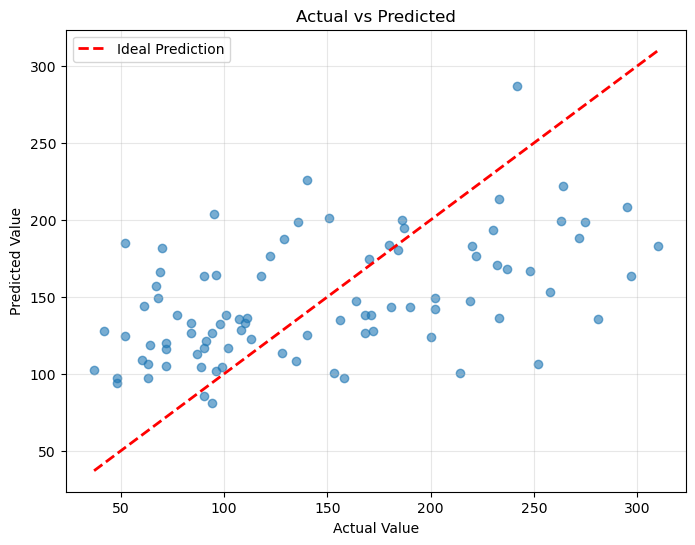

In [29]:
## 실제값과 예측값 비교

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    prediction,
    alpha=0.6
)

# 이상적인 예측선
min_value = min(
    y_test.min(),
    prediction.min()
)

max_value = max(
    y_test.max(),
    prediction.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")

plt.title("Actual vs Predicted")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## 실제값과 예측값 비교

회귀모델이 얼마나 실제 데이터를 잘 예측하는지 확인하기 위해

실제값(y_test)과 예측값(prediction)을 시각화하였다.

점들이 대각선에 가까울수록 예측 성능이 좋은 모델이라고 볼 수 있다.

## 결과 해석

실제값과 예측값을 비교한 결과,

일부 구간에서는 예측이 실제값과 유사하게 이루어졌으나
전체적으로 오차가 존재하는 것을 확인할 수 있었다.

BMI 변수 하나만 사용하여 모델을 구성하였기 때문에
설명 가능한 정보가 제한적이었다.

그럼에도 불구하고 실제값과 예측값 사이에
일정 수준의 양의 관계가 나타나는 것을 확인하였다.

## 최종 결과

최종 모델 설정

- Learning Rate : 0.07
- Epoch : 5000

최종 성능

- Train Loss : 3952.14
- Test MSE : 3935.82

프로젝트 요구사항인 회귀모델 구현,
데이터 시각화,
예측 결과 확인 과정을 모두 수행하였다.

BMI 변수와 target 간에는
상관관계가 존재하였으나,

단일 변수만 사용한 모델의 한계로 인해
MSE 3000 이하 달성에는 어려움이 있었다.

향후 여러 변수를 함께 사용한다면
예측 성능을 더욱 향상시킬 수 있을 것으로 예상된다.

## 프로젝트 회고

이번 프로젝트에서는
Gradient Descent를 직접 구현하여
회귀모델이 학습되는 과정을 확인할 수 있었다.

특히 Learning Rate와 Epoch 값을 변경하면서
모델 성능이 달라지는 것을 직접 확인할 수 있었다.

BMI 변수 하나만으로는
예측 정확도에 한계가 있었지만

머신러닝 모델의 학습 원리와
하이퍼파라미터의 중요성을 이해하는 데 도움이 되었다.

# 프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?

## 프로젝트 목표

Bike Sharing Demand 데이터를 활용하여 자전거 대여량(count)을 예측하는 회귀 모델을 구축한다.

---



In [30]:
## 데이터 불러오기

import pandas as pd

# 데이터 불러오기
train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv")

# 데이터 구조 확인
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [31]:
## 데이터 정보 확인

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [32]:
# datetime 형식으로 변환

train["datetime"] = pd.to_datetime(train["datetime"])

# 날짜 관련 변수 생성

train["year"] = train["datetime"].dt.year
train["month"] = train["datetime"].dt.month
train["day"] = train["datetime"].dt.day

train["hour"] = train["datetime"].dt.hour
train["minute"] = train["datetime"].dt.minute
train["second"] = train["datetime"].dt.second

train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,0,0


## datetime 컬럼 전처리

datetime 컬럼을 datetime 자료형으로 변환한 후

- year
- month
- day
- hour
- minute
- second

컬럼을 생성했다.

In [33]:
# datetime 형식으로 변환

train["datetime"] = pd.to_datetime(train["datetime"])

# 날짜 관련 변수 생성

train["year"] = train["datetime"].dt.year
train["month"] = train["datetime"].dt.month
train["day"] = train["datetime"].dt.day

train["hour"] = train["datetime"].dt.hour
train["minute"] = train["datetime"].dt.minute
train["second"] = train["datetime"].dt.second

train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,0,0


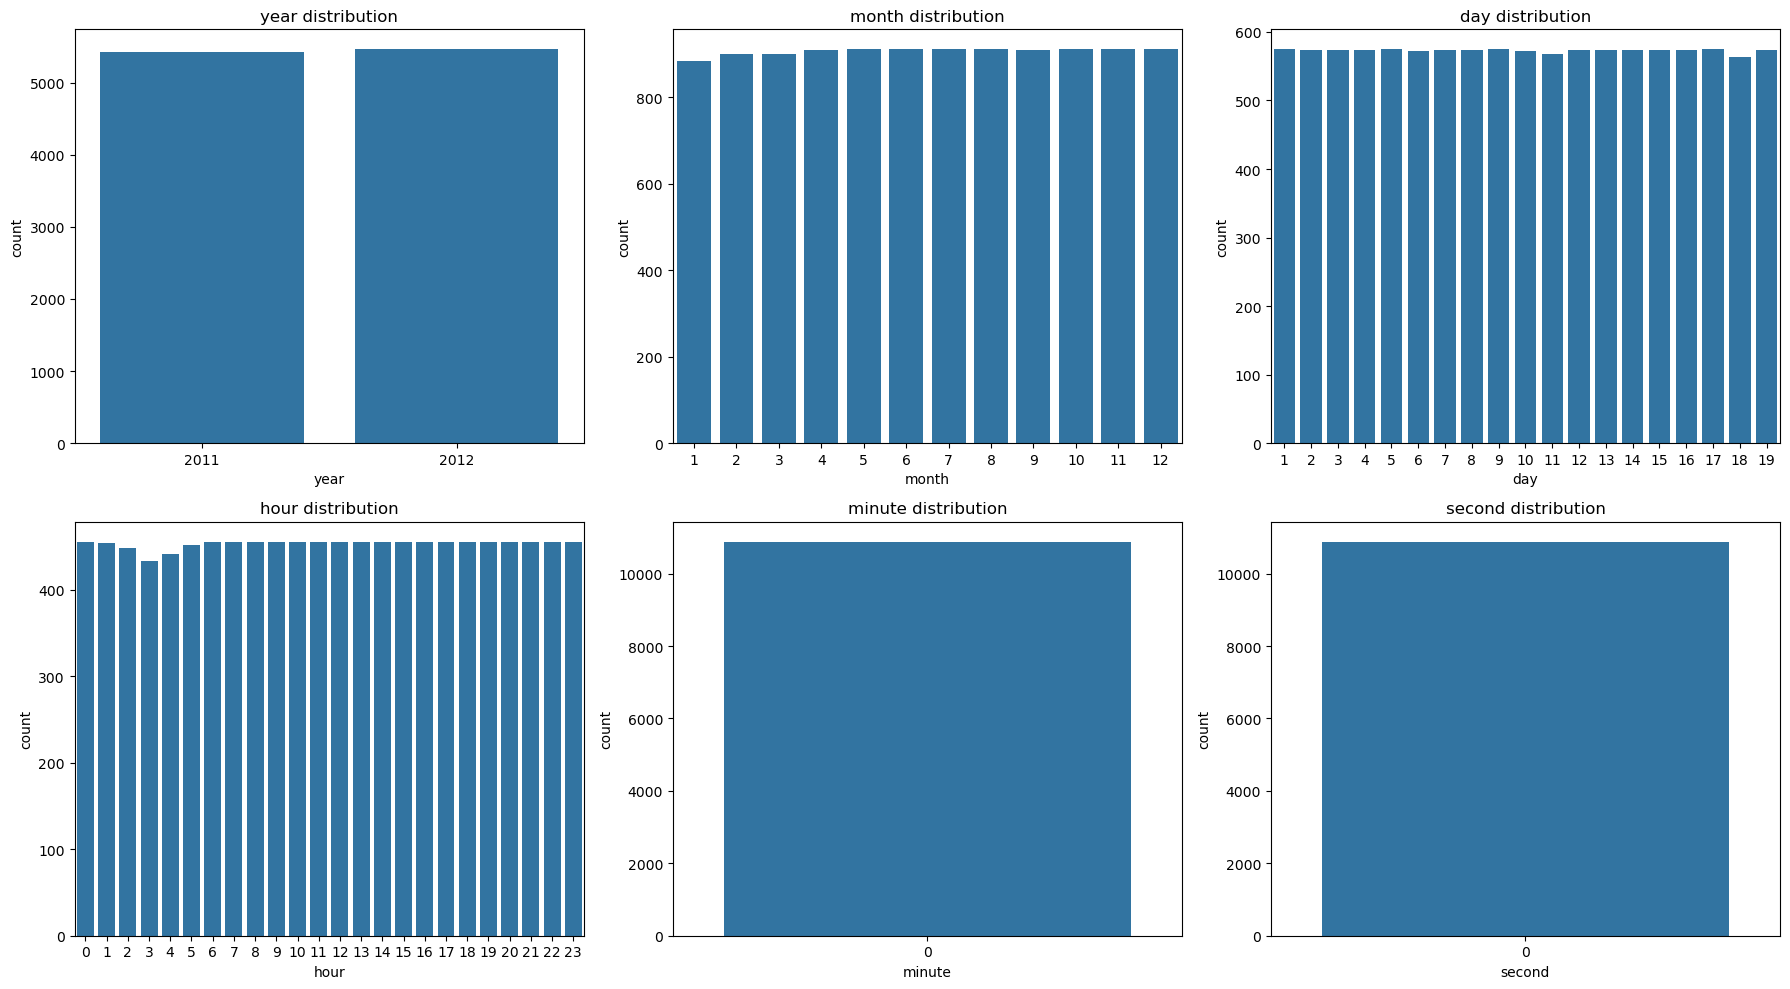

In [34]:
## datetime 변수 시각화

import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "year",
    "month",
    "day",
    "hour",
    "minute",
    "second"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

for ax, col in zip(axes.flatten(), columns):
    sns.countplot(
        x=col,
        data=train,
        ax=ax
    )
    ax.set_title(f"{col} distribution")

plt.tight_layout()
plt.show()

### 시각화 결과 해석

- 데이터는 2011년과 2012년으로 구성되어 있다.
- hour 변수는 0~23시까지 비교적 고르게 분포한다.
- minute와 second는 대부분 0으로 구성되어 있다.

In [35]:
## Feature 선택 및 데이터 분리

# 예측 대상(Target)은 count 컬럼이다.

from sklearn.model_selection import train_test_split

# 사용할 Feature 선택

features = [
    "year",
    "month",
    "day",
    "hour",
    "temp",
    "humidity",
    "windspeed"
]

X = train[features]
y = train["count"]

# train/test 분리

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8708, 7)
(2178, 7)


In [36]:
## LinearRegression 모델 학습

from sklearn.linear_model import LinearRegression

# 모델 생성

model = LinearRegression()

# 모델 학습

model.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
## 예측 및 RMSE 계산

from sklearn.metrics import mean_squared_error
import numpy as np

# 예측 수행

y_pred = model.predict(X_test)

# MSE 계산

mse = mean_squared_error(
    y_test,
    y_pred
)

# RMSE 계산

rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE :", rmse)

MSE : 19961.901814435438
RMSE : 141.2865946027274


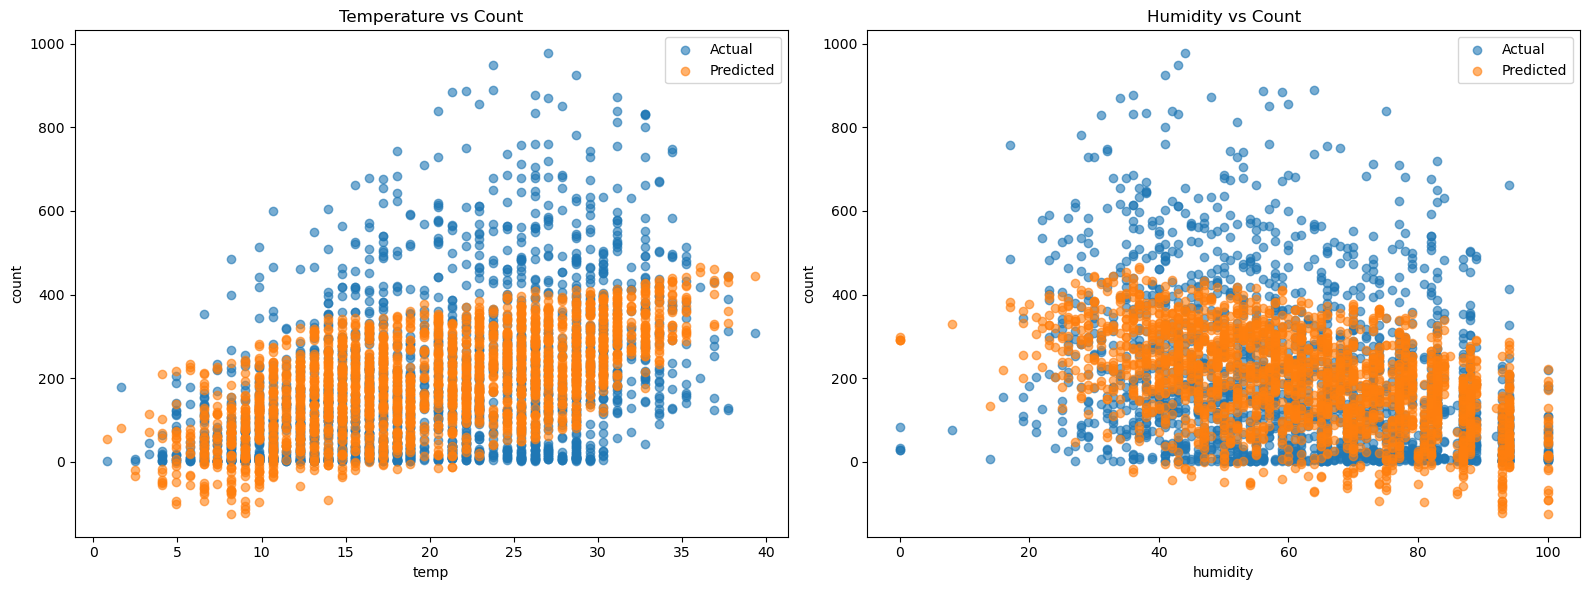

In [38]:
## 예측 결과 시각화

# 실제값과 예측값을 비교한다.

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# temp 시각화

axes[0].scatter(
    X_test["temp"],
    y_test,
    label="Actual",
    alpha=0.6
)

axes[0].scatter(
    X_test["temp"],
    y_pred,
    label="Predicted",
    alpha=0.6
)

axes[0].set_title("Temperature vs Count")
axes[0].set_xlabel("temp")
axes[0].set_ylabel("count")
axes[0].legend()


# humidity 시각화

axes[1].scatter(
    X_test["humidity"],
    y_test,
    label="Actual",
    alpha=0.6
)

axes[1].scatter(
    X_test["humidity"],
    y_pred,
    label="Predicted",
    alpha=0.6
)

axes[1].set_title("Humidity vs Count")
axes[1].set_xlabel("humidity")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()

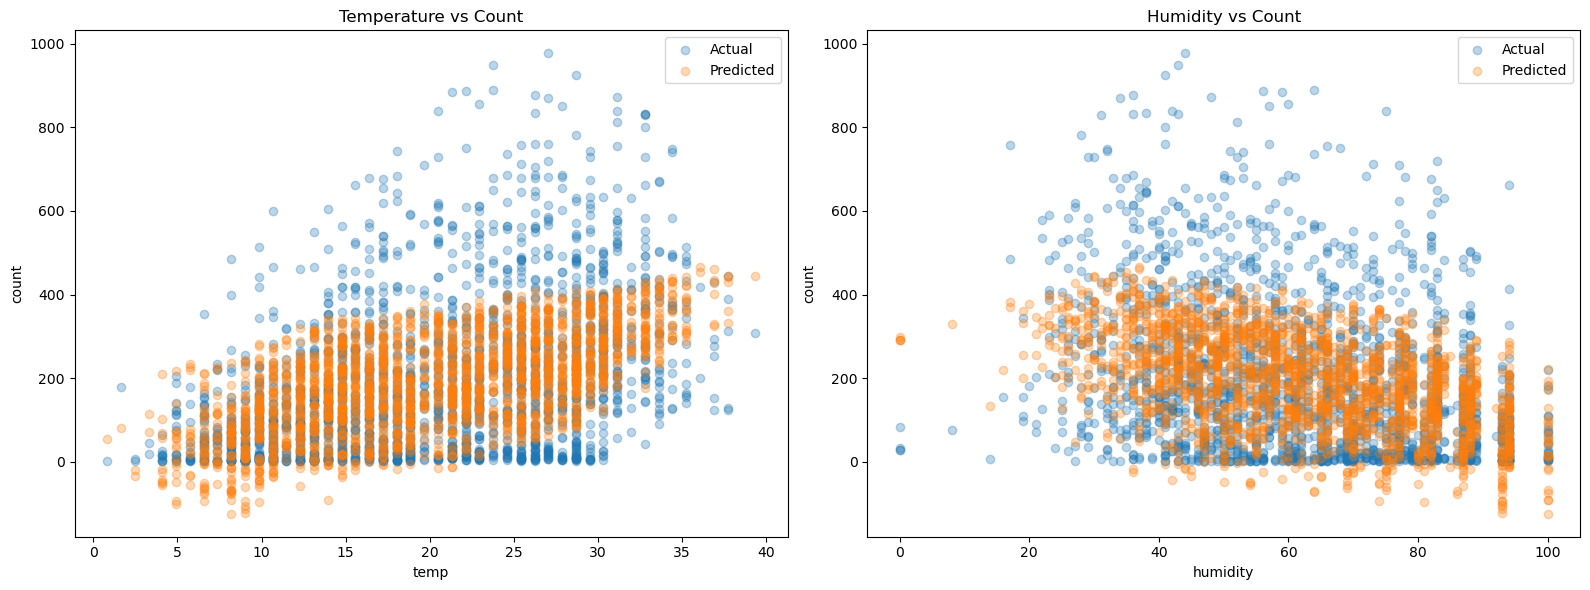

In [39]:
## 예측 결과 시각화 가독성 개선

# 실제값과 예측값을 비교한다.

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

# temp 시각화

axes[0].scatter(
    X_test["temp"],
    y_test,
    label="Actual",
    alpha=0.3
)

axes[0].scatter(
    X_test["temp"],
    y_pred,
    label="Predicted",
    alpha=0.3
)

axes[0].set_title("Temperature vs Count")
axes[0].set_xlabel("temp")
axes[0].set_ylabel("count")
axes[0].legend()


# humidity 시각화

axes[1].scatter(
    X_test["humidity"],
    y_test,
    label="Actual",
    alpha=0.3
)

axes[1].scatter(
    X_test["humidity"],
    y_pred,
    label="Predicted",
    alpha=0.3
)

axes[1].set_title("Humidity vs Count")
axes[1].set_xlabel("humidity")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()

## 그래프 가독성 개선

기존 시각화에서는 실제값(Actual)과 예측값(Predicted)이 많이 겹쳐 데이터 분포를 확인하기 어려운 부분이 있었다.

이를 개선하기 위해 scatter plot의 투명도(alpha)를 0.6에서 0.3으로 조정하였다.

투명도를 낮춤으로써 데이터가 중첩되는 구간의 밀도를 더욱 명확하게 확인할 수 있었으며, 실제값과 예측값의 분포 차이를 보다 직관적으로 파악할 수 있었다.

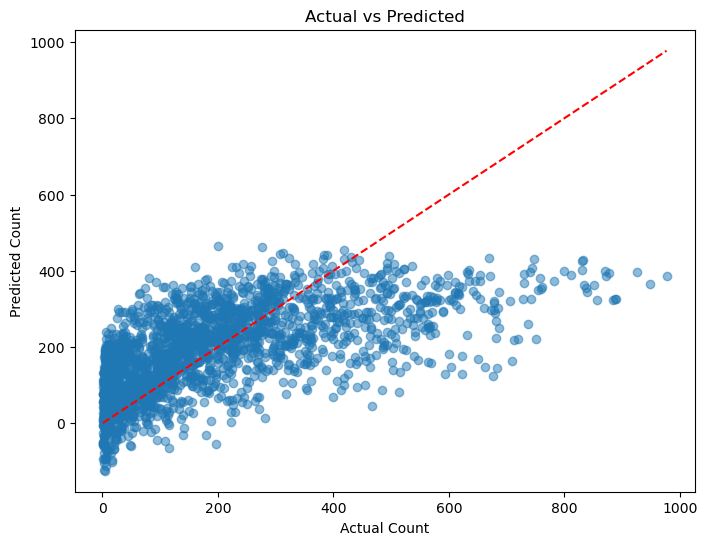

In [40]:
## Actual vs Predicted 시각화

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.show()

## Actual vs Predicted 시각화 결과해석

모델의 예측 성능을 보다 직관적으로 확인하기 위해 실제 대여량(Actual)과 예측 대여량(Predicted)의 관계를 시각화하였다.

그래프의 빨간 점선은 실제값과 예측값이 완전히 일치하는 이상적인 기준선(y=x)을 의미한다.

대부분의 데이터가 기준선 주변에 분포하고 있어 모델이 전반적인 대여량 변화 추세를 비교적 잘 학습한 것으로 판단된다.

다만 일부 구간에서는 실제값과 예측값의 차이가 크게 나타나는 데이터도 존재하며, 이는 선형회귀 모델의 한계와 데이터의 복잡한 패턴 때문으로 볼 수 있다.

그럼에도 RMSE가 141.29로 평가 기준인 150 이하를 만족하므로 본 프로젝트의 목표를 성공적으로 달성하였다.


## 목표 달성 여부 분석

프로젝트 평가 기준은 RMSE 150 이하 달성이다.

모델 학습 결과 RMSE 값은 141.29로 측정되었다.

141.29는 평가 기준인 150 이하를 만족하므로 목표를 달성하였다.

따라서 현재 Linear Regression 모델은 자전거 대여량 예측 문제에서 기준 이상의 성능을 보였다.

## 프로젝트 회고

이번 프로젝트에서는 datetime 데이터를 활용하여 연도, 월, 일, 시, 분, 초 정보를 추출하고 이를 회귀모델 학습에 활용하였다.

Linear Regression 모델을 이용하여 자전거 대여량을 예측하였으며 RMSE 141.29를 기록하여 프로젝트 목표를 달성하였다.

향후에는 season, weather, holiday, workingday 등의 추가 변수를 활용하거나 RandomForest, XGBoost와 같은 비선형 모델을 적용하여 성능을 더욱 향상시킬 수 있을 것으로 생각된다.